# 5 — Messy on purpose: a group data-cleaning lab

**Synthetic Grade 6–8 mathematics data · local analysis · no student records sent to an AI**

In this lab, the group will decide what should count as a usable record before interpreting differences associated with economic background, demographics, attendance, testing time, and program participation.

The goal is not to discover one “correct” cleaned dataset. The goal is to make consequential choices visible, document them, and see how they change the story.

> **Language matters:** these are descriptive associations in synthetic observational data. “Isolate” here means comparing estimates after accounting for selected measured factors—not proving that any characteristic caused an outcome.

## How to facilitate the exercise

At each decision stop:

1. **Look first.** Describe what is visible before changing anything.
2. **Vote on a policy.** Ask what should be corrected, flagged, excluded, or left alone.
3. **Ask the local agent.** Use the supplied prompt or ask in plain language. The agent should write and run code locally without displaying student-level rows.
4. **Record the decision.** State the rationale and who could be affected.
5. **Compare.** Re-run the summary or chart and ask whether the conclusion changed.

The notebook includes a defensible reference path so it runs from top to bottom. Change the policy cells during the live session when the group chooses another reasonable path.

**Privacy rule:** prompts describe columns and requested operations. Do not paste rows, identifiers, screenshots containing records, or CSV contents into a remote chat.

## The scenario

A district exported one Spring mathematics administration per student—or so it expected. The file also contains Fall baseline scores, student characteristics, attendance, scheduling information, and administration conditions.

The team wants to explore:

- whether Spring scores and Fall-to-Spring growth differ by economic background;
- whether observed demographic patterns remain after grade and baseline differences are considered;
- whether morning and afternoon administrations look different;
- whether attendance, interruptions, makeup testing, and targeted program participation change the interpretation; and
- which findings are stable when plausible outliers are included or excluded.

Before answering any of those questions, we need to decide what the rows and values mean.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)
sns.set_theme(style="whitegrid", context="notebook")


def locate_file(filename):
    # Find a workshop file from either the project root or notebooks folder.
    for folder in (Path.cwd(), Path.cwd().parent):
        candidate = folder / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename!r} in this folder or its parent.")


DATA_PATH = locate_file("MessyAssessmentData.csv")
SCHEMA_PATH = locate_file("MessyAssessmentDataSchema.csv")

# Read everything as text first. Type conversion is a decision, not an assumption.
raw = pd.read_csv(DATA_PATH, dtype="string", keep_default_na=False)
schema = pd.read_csv(SCHEMA_PATH)

print(
    f"Loaded {len(raw):,} exported rows, {raw['student_key'].nunique():,} "
    f"synthetic student keys, and {raw.shape[1]} columns."
)

Loaded 254 exported rows, 240 synthetic student keys, and 19 columns.


## Stop 1 — What is one record?

Before looking at averages, establish the intended unit of analysis.

**Discuss:**

- Should there be one row per student, one row per attempt, or one row per valid administration?
- Is an exact duplicate the same problem as a student with two attempts?
- If a first attempt was invalidated, should the retest replace it?
- What policy should govern two completed attempts when neither is marked invalid?

**Prompt for the local agent:**

> Using the local pandas dataframe `raw` and dataframe `schema`, audit the file without displaying student-level rows or keys. Report row count, distinct student count, exact duplicate count, students with multiple rows, missing-marker counts, distinct label counts, and parseability of intended numeric/date fields. Separate exact duplicates from multiple attempts. Do not clean or exclude anything yet. Return aggregate tables and explain what policy decisions are still needed.

In [2]:
blank_markers = {"", "na", "n/a", "absent", "—", "unknown", "not reported", "not recorded"}

audit = []
for column in raw.columns:
    normalized = raw[column].str.strip().str.lower()
    audit.append(
        {
            "field": column,
            "export_type": str(raw[column].dtype),
            "distinct_raw_values": int(raw[column].nunique()),
            "blank_or_marker_cells": int(normalized.isin(blank_markers).sum()),
        }
    )

deduped_for_audit = raw.drop_duplicates()
duplicate_audit = pd.DataFrame(
    {
        "question": [
            "Exported rows",
            "Distinct student keys",
            "Exact duplicate rows",
            "Rows beyond one per student",
            "Students represented by multiple export rows",
            "Rows beyond one after exact-duplicate removal",
            "Students with multiple non-identical attempts",
        ],
        "count": [
            len(raw),
            raw["student_key"].nunique(),
            int(raw.duplicated().sum()),
            len(raw) - raw["student_key"].nunique(),
            int(raw.groupby("student_key").size().gt(1).sum()),
            len(deduped_for_audit) - deduped_for_audit["student_key"].nunique(),
            int(deduped_for_audit.groupby("student_key").size().gt(1).sum()),
        ],
    }
)

display(duplicate_audit)
display(pd.DataFrame(audit))

,question,count
0,Exported rows,254
1,Distinct student keys,240
2,Exact duplicate rows,5
3,Rows beyond one per student,14
4,Students represented by multiple export rows,14
5,Rows beyond one after exact-duplicate removal,9
6,Students with multiple non-identical attempts,9


,field,export_type,distinct_raw_values,blank_or_marker_cells
0,student_key,string,240,0
1,grade,string,15,0
2,race_ethnicity,string,17,8
3,gender,string,15,3
4,economically_disadvantaged,string,14,7
5,mll,string,14,5
6,iep,string,14,4
7,attendance_rate,string,148,1
8,fall_score,string,155,5
9,spring_score,string,158,4


In [3]:
category_fields = [
    "grade",
    "race_ethnicity",
    "gender",
    "economically_disadvantaged",
    "mll",
    "iep",
    "time_of_day",
    "device_interruption",
    "after_school_program",
    "record_status",
]

label_audit = pd.DataFrame(
    {
        "field": category_fields,
        "distinct_raw_labels": [raw[column].nunique() for column in category_fields],
        "examples": [
            " · ".join(sorted(raw[column].drop_duplicates().astype(str))[:16])
            for column in category_fields
        ],
    }
)
label_audit

,field,distinct_raw_labels,examples
0,grade,15,6 · 7 · 8 · 06 · 07 · 08 · 6 · 6th · 7 ·...
1,race_ethnicity,17,· African American · Asian · Black · Black/Af...
2,gender,15,· Female · Male · F · Female · M · Male ·...
3,economically_disadvantaged,14,· No · 0 · 1 · FALSE · N · No · Not Reporte...
4,mll,14,· No · 0 · 1 · FALSE · N · No · Not Reporte...
5,iep,14,· No · 0 · 1 · FALSE · N · No · Not Reporte...
6,time_of_day,8,AM · After lunch · Afternoon · Morning · PM · ...
7,device_interruption,11,No · 0 · 1 · FALSE · N · No · TRUE · Y · Yes...
8,after_school_program,11,No · 0 · 1 · FALSE · N · No · TRUE · Y · Yes...
9,record_status,3,Complete · Complete - review retest policy · I...


## Stop 2 — Normalize representation without erasing meaning

“Normalization” can mean several different things:

1. **Representation normalization:** make `Y`, `yes`, and `1` mean the same thing.
2. **Unit normalization:** convert `93`, `93%`, and `0.93` to one attendance scale.
3. **Analytic standardization:** express scores relative to a grade-specific distribution.

Only the first two belong in this cleaning step.

**Discuss:**

- Which labels are true synonyms, and which require a governance decision?
- Should missing economic, MLL, or IEP status become “No”? *(Reference answer: no.)*
- Should race/ethnicity labels be combined? Who owns that crosswalk?
- If a source time-of-day label conflicts with a parseable start time, which source wins?

**Prompt for the local agent:**

> Propose pandas code that normalizes the local `raw` dataframe using `schema`, without showing records. Preserve raw data in `raw` and create `work`. Normalize whitespace, missing markers, grade labels, yes/no indicators, gender and race/ethnicity variants, mixed attendance units, numeric score and duration strings, dates, and start times. Preserve unknown as missing rather than converting it to “No.” Derive time of day from a valid start time, flag conflicts with the source label, and report only aggregate before/after checks. Do not remove statistical outliers.

In [4]:
work = raw.drop_duplicates().copy()
exact_duplicates_removed = len(raw) - len(work)

MISSING = {"", "na", "n/a", "absent", "—", "unknown", "not recorded"}


def normalized_text(series):
    result = series.astype("string").str.strip()
    return result.mask(result.str.lower().isin(MISSING), pd.NA)


# Grade: preserve only the expected numeric grade after extracting it from labels.
work["grade"] = pd.to_numeric(
    normalized_text(work["grade"]).str.extract(r"([678])", expand=False),
    errors="coerce",
).astype("Int64")

YES_NO = {
    "yes": "Yes", "y": "Yes", "1": "Yes", "true": "Yes",
    "no": "No", "n": "No", "0": "No", "false": "No",
}
for column in [
    "economically_disadvantaged",
    "mll",
    "iep",
    "device_interruption",
    "after_school_program",
]:
    cleaned = normalized_text(work[column]).str.lower()
    work[column] = cleaned.map(YES_NO).astype("string")

GENDER = {
    "female": "Female", "f": "Female",
    "male": "Male", "m": "Male",
    "nonbinary": "Nonbinary", "non-binary": "Nonbinary", "nb": "Nonbinary",
    "not reported": "Not reported", "prefer not to say": "Not reported",
}
work["gender"] = normalized_text(work["gender"]).str.lower().map(GENDER).astype("string")

RACE_ETHNICITY = {
    "asian": "Asian",
    "black/african american": "Black/African American",
    "black": "Black/African American",
    "african american": "Black/African American",
    "hispanic/latino": "Hispanic/Latino",
    "hispanic": "Hispanic/Latino",
    "latino/a": "Hispanic/Latino",
    "multiracial": "Multiracial",
    "two or more races": "Multiracial",
    "multi-racial": "Multiracial",
    "white": "White",
    "not reported": "Not reported", "declined": "Not reported",
}
work["race_ethnicity"] = (
    normalized_text(work["race_ethnicity"]).str.lower().map(RACE_ETHNICITY).astype("string")
)

# Mixed attendance units: percentages become proportions; impossible values become missing and are flagged.
attendance_text = normalized_text(work["attendance_rate"])
attendance_had_percent_sign = attendance_text.str.contains("%", na=False)
attendance_numeric = pd.to_numeric(attendance_text.str.replace("%", "", regex=False), errors="coerce")
attendance_was_whole_percent = attendance_numeric.gt(1) & attendance_numeric.le(100)
attendance_numeric = attendance_numeric.where(~attendance_was_whole_percent, attendance_numeric / 100)
work["attendance_invalid"] = attendance_numeric.notna() & ~attendance_numeric.between(0, 1)
work["attendance_rate"] = attendance_numeric.where(attendance_numeric.between(0, 1))
work["attendance_unit_converted"] = attendance_had_percent_sign | attendance_was_whole_percent

for column in ["fall_score", "spring_score"]:
    work[column] = pd.to_numeric(normalized_text(work[column]), errors="coerce")

work["duration_minutes"] = pd.to_numeric(
    normalized_text(work["duration_minutes"]).str.extract(r"(-?\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)
work["attempt"] = pd.to_numeric(normalized_text(work["attempt"]), errors="coerce").astype("Int64")
work["test_date"] = pd.to_datetime(normalized_text(work["test_date"]), format="mixed", errors="coerce")

source_time = normalized_text(work["time_of_day"]).str.lower().map(
    {
        "morning": "Morning", "am": "Morning", "a.m.": "Morning",
        "afternoon": "Afternoon", "pm": "Afternoon", "p.m.": "Afternoon",
        "after lunch": "Afternoon",
    }
).astype("string")
parsed_time = pd.to_datetime(normalized_text(work["test_start_time"]), format="mixed", errors="coerce")
derived_time = pd.Series(pd.NA, index=work.index, dtype="string")
derived_time.loc[parsed_time.notna() & parsed_time.dt.hour.lt(12)] = "Morning"
derived_time.loc[parsed_time.notna() & parsed_time.dt.hour.ge(12)] = "Afternoon"
work["time_of_day_conflict"] = source_time.notna() & derived_time.notna() & source_time.ne(derived_time)
work["time_of_day"] = derived_time.combine_first(source_time)
work["test_start_time"] = parsed_time

work["administration_type"] = normalized_text(work["administration_type"]).str.title()
work["record_status"] = normalized_text(work["record_status"])

normalization_check = pd.DataFrame(
    {
        "check": [
            "Exact duplicate rows removed",
            "Attendance units converted",
            "Invalid attendance values set missing",
            "Unparseable test dates",
            "Unparseable start times",
            "Source/derived time-of-day conflicts flagged",
        ],
        "count": [
            exact_duplicates_removed,
            int(work["attendance_unit_converted"].sum()),
            int(work["attendance_invalid"].sum()),
            int(work["test_date"].isna().sum()),
            int(work["test_start_time"].isna().sum()),
            int(work["time_of_day_conflict"].sum()),
        ],
    }
)
normalization_check

,check,count
0,Exact duplicate rows removed,5
1,Attendance units converted,30
2,Invalid attendance values set missing,2
3,Unparseable test dates,1
4,Unparseable start times,5
5,Source/derived time-of-day conflicts flagged,10


## Stop 3 — Investigate before excluding outliers

A value can be:

- **impossible under the instrument’s rules** (for example, outside an operational score range);
- **a likely representation error** (for example, a percentage stored as `93` instead of `0.93`);
- **unusual but plausible** (for example, very large growth);
- **context-dependent** (for example, a long duration under an extended-time accommodation); or
- **influential** without being wrong.

The next charts deliberately use the normalized-but-not-filtered data.

**Discuss:**

- Which points are impossible, and which are merely surprising?
- Should duration thresholds differ by administration type or accommodation context?
- Does an IQR rule provide evidence that a value is wrong?
- What documentation would you seek before excluding a plausible score?

,flag,rows_flagged
0,Fall score outside 100–800,1
1,Spring score outside 100–800,2
2,Growth outside 1.5×IQR fences,6
3,Duration under 10 minutes,1
4,Duration over 180 minutes,2
5,Invalidated record status,7
6,Time-of-day label conflict,10


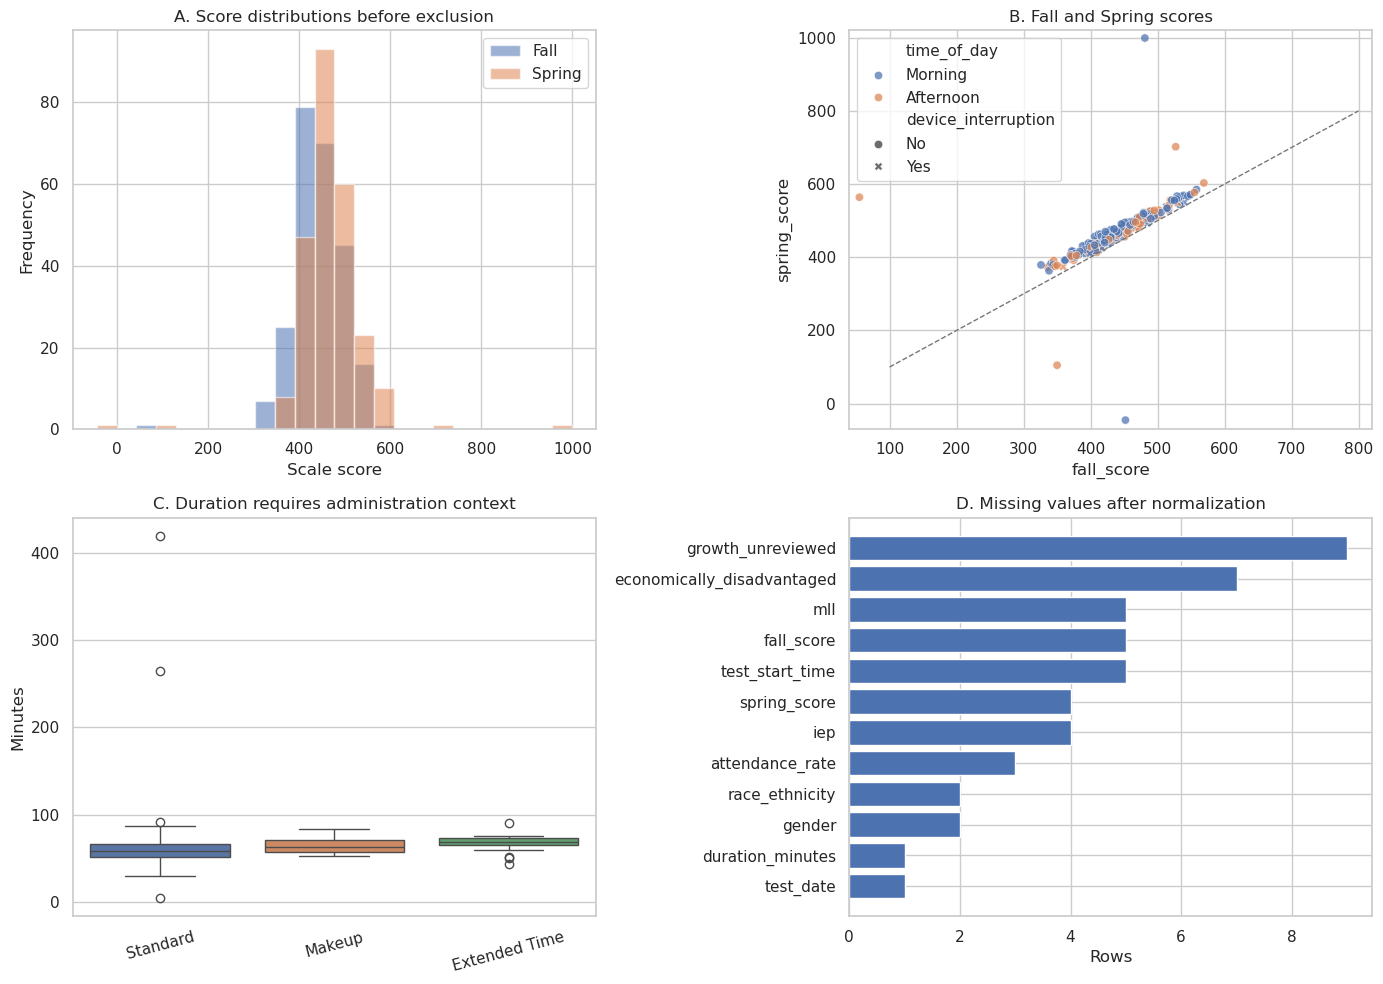

In [5]:
work["growth_unreviewed"] = work["spring_score"] - work["fall_score"]
work["fall_outside_operational_range"] = work["fall_score"].notna() & ~work["fall_score"].between(100, 800)
work["spring_outside_operational_range"] = work["spring_score"].notna() & ~work["spring_score"].between(100, 800)
work["duration_under_10"] = work["duration_minutes"].notna() & work["duration_minutes"].lt(10)
work["duration_over_180"] = work["duration_minutes"].notna() & work["duration_minutes"].gt(180)

q1, q3 = work["growth_unreviewed"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_growth_bound = q1 - 1.5 * iqr
upper_growth_bound = q3 + 1.5 * iqr
work["growth_iqr_flag"] = work["growth_unreviewed"].notna() & ~work["growth_unreviewed"].between(
    lower_growth_bound, upper_growth_bound
)

flag_summary = pd.DataFrame(
    {
        "flag": [
            "Fall score outside 100–800",
            "Spring score outside 100–800",
            "Growth outside 1.5×IQR fences",
            "Duration under 10 minutes",
            "Duration over 180 minutes",
            "Invalidated record status",
            "Time-of-day label conflict",
        ],
        "rows_flagged": [
            int(work["fall_outside_operational_range"].sum()),
            int(work["spring_outside_operational_range"].sum()),
            int(work["growth_iqr_flag"].sum()),
            int(work["duration_under_10"].sum()),
            int(work["duration_over_180"].sum()),
            int(work["record_status"].str.lower().str.startswith("invalid", na=False).sum()),
            int(work["time_of_day_conflict"].sum()),
        ],
    }
)
display(flag_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

work[["fall_score", "spring_score"]].rename(
    columns={"fall_score": "Fall", "spring_score": "Spring"}
).plot.hist(bins=24, alpha=0.55, ax=axes[0, 0])
axes[0, 0].set(title="A. Score distributions before exclusion", xlabel="Scale score")

sns.scatterplot(
    data=work,
    x="fall_score",
    y="spring_score",
    hue="time_of_day",
    style="device_interruption",
    alpha=0.72,
    ax=axes[0, 1],
)
axes[0, 1].plot([100, 800], [100, 800], "--", color="#777777", linewidth=1)
axes[0, 1].set(title="B. Fall and Spring scores", xlim=(40, 820), ylim=(-70, 1020))

sns.boxplot(
    data=work,
    x="administration_type",
    y="duration_minutes",
    hue="administration_type",
    legend=False,
    ax=axes[1, 0],
)
axes[1, 0].set(title="C. Duration requires administration context", xlabel="", ylabel="Minutes")
axes[1, 0].tick_params(axis="x", rotation=15)

missing_counts = work.isna().sum().sort_values(ascending=False).head(12)
axes[1, 1].barh(missing_counts.index[::-1], missing_counts.values[::-1], color="#4C72B0")
axes[1, 1].set(title="D. Missing values after normalization", xlabel="Rows")

plt.tight_layout()
plt.show()

### Agent prompt: turn the group’s decisions into a record-selection policy

> Using local dataframe `work`, implement our agreed record-selection policy and produce an attrition table. Always remove exact duplicates. Prefer a completed retest over a specifically invalidated attempt. For two completed attempts, apply the policy we state explicitly rather than silently choosing. Treat Fall and Spring values outside the documented 100–800 range as invalid. Flag—but do not automatically remove—large IQR growth values or unusual durations. Return one row per student as `selected`, a score-valid subset as `analysis`, and aggregate counts only. Add assertions for one record per student and documented exclusions.

The reference policy below chooses the latest completed attempt when two completed attempts remain. That is a policy choice, not a universal rule.

In [6]:
# REFERENCE POLICY — change this when the group chooses a different completed-retest rule.
COMPLETED_RETEST_POLICY = "latest_completed_attempt"  # Alternative: "earliest_completed_attempt"
MIN_DISPLAYED_GROUP_SIZE = 10

if COMPLETED_RETEST_POLICY not in {"latest_completed_attempt", "earliest_completed_attempt"}:
    raise ValueError("State an implemented completed-retest policy before selecting records.")
attempt_ascending = COMPLETED_RETEST_POLICY == "earliest_completed_attempt"

selection = work.copy()
selection["status_is_invalid"] = selection["record_status"].str.lower().str.startswith("invalid", na=False)
selection["score_pair_present"] = selection[["fall_score", "spring_score"]].notna().all(axis=1)
selection["scores_in_operational_range"] = (
    selection["fall_score"].between(100, 800)
    & selection["spring_score"].between(100, 800)
)

# Valid status first, then a complete/in-range pair, then the selected attempt policy.
selection = selection.sort_values(
    ["student_key", "status_is_invalid", "score_pair_present", "scores_in_operational_range", "attempt"],
    ascending=[True, True, False, False, attempt_ascending],
)
selected = selection.drop_duplicates("student_key", keep="first").copy()

assert selected["student_key"].is_unique
assert len(selected) == raw["student_key"].nunique()

selected["growth"] = selected["spring_score"] - selected["fall_score"]
selected["score_pair_usable"] = (
    ~selected["status_is_invalid"]
    & selected[["fall_score", "spring_score"]].notna().all(axis=1)
    & selected["fall_score"].between(100, 800)
    & selected["spring_score"].between(100, 800)
)

analysis = selected.loc[selected["score_pair_usable"]].copy()
q1, q3 = analysis["growth"].quantile([0.25, 0.75])
iqr = q3 - q1
analysis["growth_iqr_flag"] = ~analysis["growth"].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

attrition = pd.DataFrame(
    {
        "stage": [
            "Raw export rows",
            "After exact-duplicate removal",
            "One selected record per student",
            "Usable operational score pair",
            "Sensitivity set after excluding IQR growth flags",
        ],
        "rows": [
            len(raw),
            len(work),
            len(selected),
            len(analysis),
            int((~analysis["growth_iqr_flag"]).sum()),
        ],
    }
)
attrition

,stage,rows
0,Raw export rows,254
1,After exact-duplicate removal,249
2,One selected record per student,240
3,Usable operational score pair,230
4,Sensitivity set after excluding IQR growth flags,227


## Stop 4 — Choose what should be standardized

Scale scores differ by grade. A raw score comparison can partly reflect that mixture. We will preserve scale scores and growth in their original units, then add within-grade standardized values for one additional lens.

A z-score answers: **How far above or below the synthetic grade’s mean was this score, in standard-deviation units?**

It does **not**:

- repair invalid data;
- make unlike assessments automatically comparable;
- remove confounding;
- turn a descriptive gap into a causal effect; or
- determine whether a difference is educationally meaningful.

**Discuss:** Should standardization happen within grade, grade-and-season, school, or another norming group? What comparison does each choice support?

In [7]:
def zscore_within_group(series):
    standard_deviation = series.std(ddof=0)
    if pd.isna(standard_deviation) or standard_deviation == 0:
        return pd.Series(pd.NA, index=series.index, dtype="Float64")
    return (series - series.mean()) / standard_deviation


analysis["fall_z_within_grade"] = analysis.groupby("grade")["fall_score"].transform(zscore_within_group)
analysis["spring_z_within_grade"] = analysis.groupby("grade")["spring_score"].transform(zscore_within_group)
analysis["standardized_change"] = analysis["spring_z_within_grade"] - analysis["fall_z_within_grade"]

standardization_check = (
    analysis.groupby("grade")[["fall_z_within_grade", "spring_z_within_grade"]]
    .agg(["count", "mean", "std"])
    .round(3)
)
standardization_check

fall_z_within_grade             spring_z_within_grade            
                    count mean    std                 count mean    std
grade                                                                  
6                      75  0.0  1.007                    75  0.0  1.007
7                      82  0.0  1.006                    82 -0.0  1.006
8                      73  0.0  1.007                    73 -0.0  1.007

## Stop 5 — Explore visible patterns before trying to “isolate” anything

Read each chart as a question generator:

- Is the economic-background difference more visible in Spring status or in growth?
- Does time of day appear related to growth? Who is disproportionately tested in the afternoon?
- Is attendance associated with growth, and could attendance also reflect opportunity or access?
- Are after-school program participants comparable to nonparticipants, or was support targeted?
- Which demographic results are too small to display responsibly?

Never rank individual students, classes, or teachers from these exploratory views.

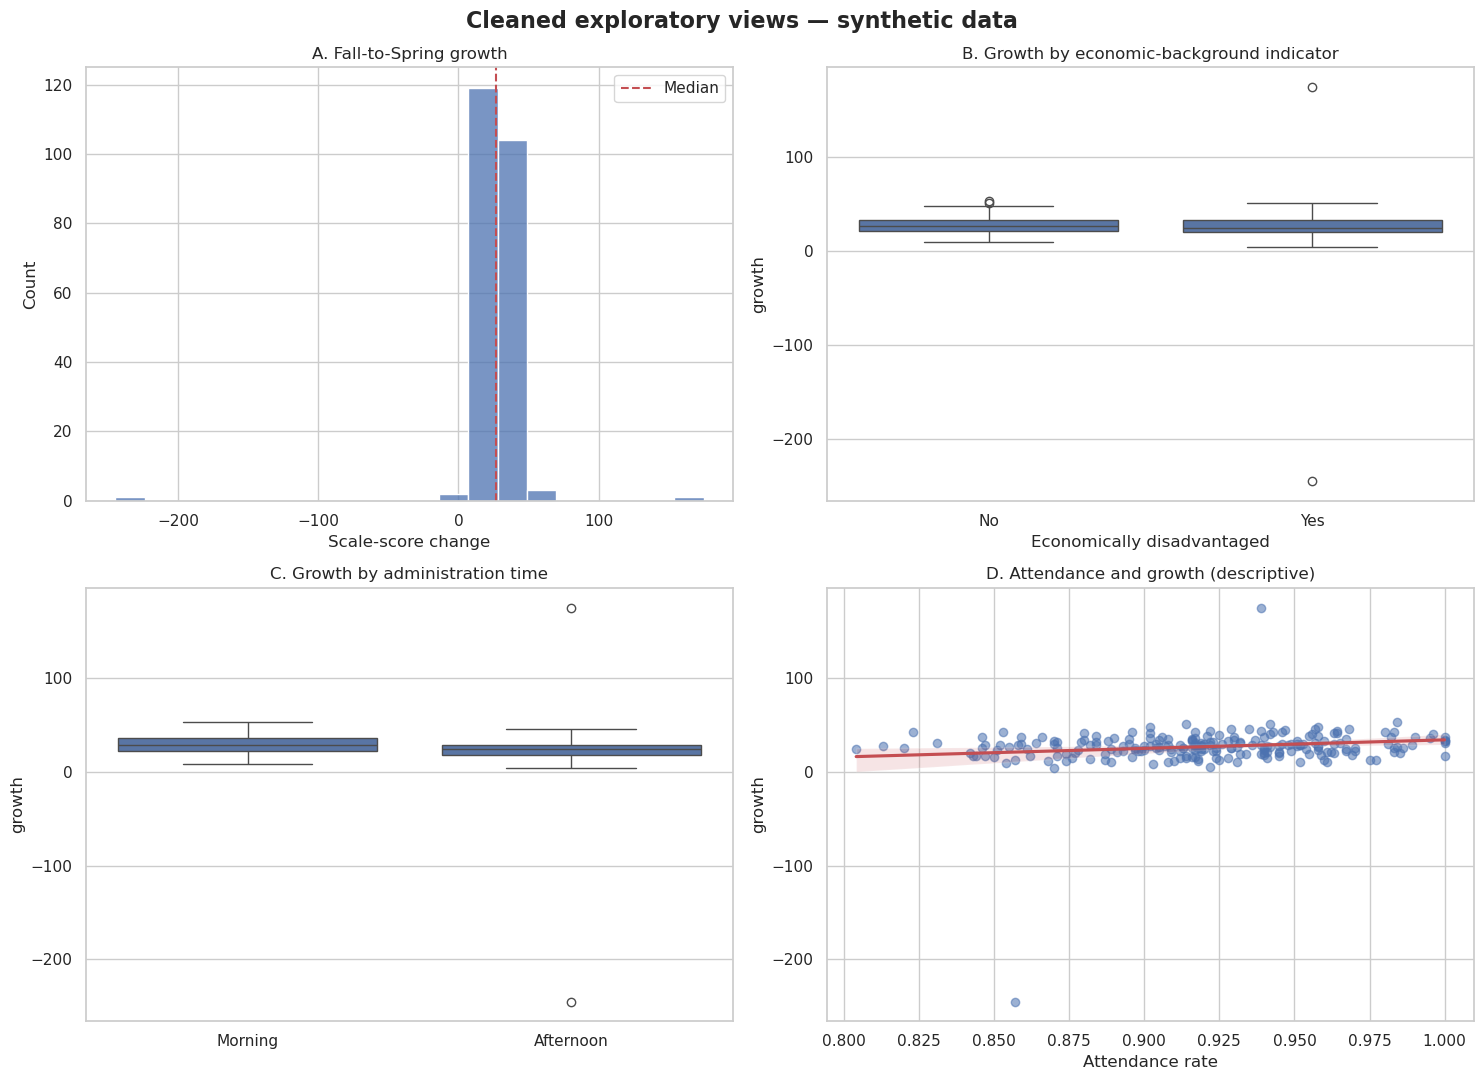

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.histplot(data=analysis, x="growth", bins=20, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].axvline(analysis["growth"].median(), color="#C44E52", linestyle="--", label="Median")
axes[0, 0].set(title="A. Fall-to-Spring growth", xlabel="Scale-score change")
axes[0, 0].legend()

sns.boxplot(
    data=analysis,
    x="economically_disadvantaged",
    y="growth",
    order=["No", "Yes"],
    ax=axes[0, 1],
)
axes[0, 1].set(title="B. Growth by economic-background indicator", xlabel="Economically disadvantaged")

sns.boxplot(
    data=analysis,
    x="time_of_day",
    y="growth",
    order=["Morning", "Afternoon"],
    ax=axes[1, 0],
)
axes[1, 0].set(title="C. Growth by administration time", xlabel="")

sns.regplot(
    data=analysis,
    x="attendance_rate",
    y="growth",
    scatter_kws={"alpha": 0.55},
    line_kws={"color": "#C44E52"},
    ax=axes[1, 1],
)
axes[1, 1].set(title="D. Attendance and growth (descriptive)", xlabel="Attendance rate")

fig.suptitle("Cleaned exploratory views — synthetic data", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

dimension,group,spring_mean,growth_mean,spring_z_mean,display_n
Economic background,No,475.6,28.0,0.19,121
Economic background,Yes,457.2,25.2,-0.27,102
Economic background,suppressed,suppressed,suppressed,suppressed,<10
Race/ethnicity,Asian,480.8,27.9,0.26,26
Race/ethnicity,Black/African American,465.0,27.1,-0.09,55
Race/ethnicity,Hispanic/Latino,474.3,25.9,0.11,73
Race/ethnicity,Multiracial,468.4,24.3,0.08,10
Race/ethnicity,Not reported,suppressed,suppressed,suppressed,<10
Race/ethnicity,White,462.0,27.3,-0.10,57
Race/ethnicity,suppressed,suppressed,suppressed,suppressed,<10


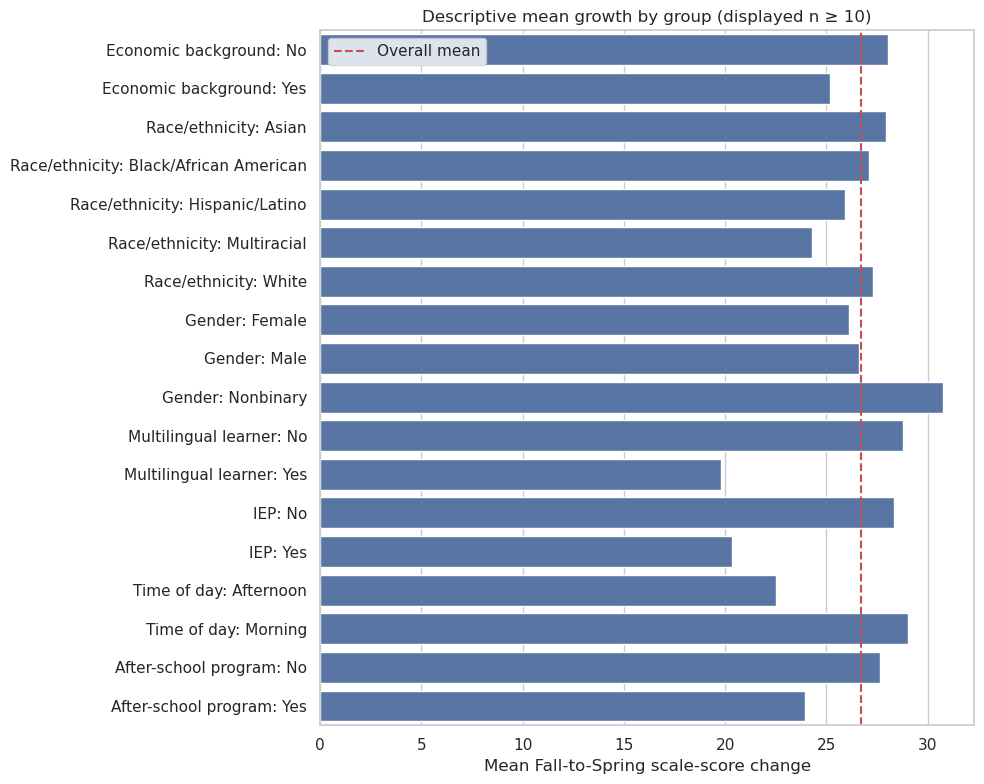

,dimension,group,spring_mean,growth_mean,spring_z_mean,display_n
0,Economic background,No,475.595041,28.041322,0.19281,121
1,Economic background,Yes,457.156863,25.186275,-0.268727,102
2,Economic background,<NA>,<NA>,<NA>,<NA>,<10
3,Race/ethnicity,Asian,480.807692,27.923077,0.257901,26
4,Race/ethnicity,Black/African American,464.981818,27.090909,-0.085936,55
5,Race/ethnicity,Hispanic/Latino,474.328767,25.931507,0.11027,73
6,Race/ethnicity,Multiracial,468.4,24.3,0.077903,10
7,Race/ethnicity,Not reported,<NA>,<NA>,<NA>,<10
8,Race/ethnicity,White,462.017544,27.280702,-0.10481,57
9,Race/ethnicity,<NA>,<NA>,<NA>,<NA>,<10


In [9]:
def subgroup_summary(data, dimension, label):
    summary = (
        data.groupby(dimension, dropna=False)
        .agg(
            n=("student_key", "size"),
            spring_mean=("spring_score", "mean"),
            growth_mean=("growth", "mean"),
            spring_z_mean=("spring_z_within_grade", "mean"),
        )
        .reset_index()
        .rename(columns={dimension: "group"})
    )
    summary.insert(0, "dimension", label)
    eligible = summary["n"].ge(MIN_DISPLAYED_GROUP_SIZE)
    summary["display_n"] = summary["n"].astype("string").where(
        eligible, f"<{MIN_DISPLAYED_GROUP_SIZE}"
    )
    for measure in ["spring_mean", "growth_mean", "spring_z_mean"]:
        summary[measure] = summary[measure].where(eligible)
    return summary.drop(columns="n")


subgroups = pd.concat(
    [
        subgroup_summary(analysis, "economically_disadvantaged", "Economic background"),
        subgroup_summary(analysis, "race_ethnicity", "Race/ethnicity"),
        subgroup_summary(analysis, "gender", "Gender"),
        subgroup_summary(analysis, "mll", "Multilingual learner"),
        subgroup_summary(analysis, "iep", "IEP"),
        subgroup_summary(analysis, "time_of_day", "Time of day"),
        subgroup_summary(analysis, "after_school_program", "After-school program"),
    ],
    ignore_index=True,
)

display(
    subgroups.style.format(
        {"spring_mean": "{:.1f}", "growth_mean": "{:.1f}", "spring_z_mean": "{:.2f}"},
        na_rep="suppressed",
    ).hide(axis="index")
)

eligible_groups = subgroups.dropna(subset=["growth_mean"]).copy()
eligible_groups["group_label"] = (
    eligible_groups["dimension"] + ": " + eligible_groups["group"].astype(str)
)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=eligible_groups,
    y="group_label",
    x="growth_mean",
    color="#4C72B0",
    ax=ax,
)
ax.axvline(analysis["growth"].mean(), color="#C44E52", linestyle="--", label="Overall mean")
ax.set(
    title=f"Descriptive mean growth by group (displayed n ≥ {MIN_DISPLAYED_GROUP_SIZE})",
    xlabel="Mean Fall-to-Spring scale-score change",
    ylabel="",
)
ax.legend()
plt.tight_layout()
plt.show()
subgroups

## Stop 6 — Build an “isolation ladder,” not a magic adjustment

Compare increasingly adjusted descriptions rather than jumping directly to one model:

1. **Spring status difference:** mixes prior achievement with subsequent change.
2. **Raw growth difference:** focuses on change but remains sensitive to baseline and measurement error.
3. **Within-grade standardized difference:** changes the comparison scale, not the assignment process.
4. **Regression-adjusted association:** accounts for selected measured variables but not unmeasured factors.
5. **Sensitivity analysis:** asks whether plausible outlier choices change the conclusion.

**Prompt for the local agent:**

> Using only aggregate output from local dataframe `analysis`, build a transparent comparison ladder for economic background and time of day. Show unadjusted Spring-score differences, growth differences, within-grade standardized differences, and a baseline-adjusted descriptive regression. Include Fall score, grade, attendance, MLL, IEP, time of day, interruption, economic status, and targeted program participation only when their inclusion has a stated rationale. Use robust uncertainty, report n, suppress groups below 10, and compare results with IQR growth flags excluded. Call every estimate an association, list omitted-variable and selection limitations, and make no causal claims.

In [10]:
def difference(data, group, outcome, first="Yes", reference="No"):
    means = data.groupby(group)[outcome].mean()
    if first not in means or reference not in means:
        return np.nan
    return means[first] - means[reference]


afternoon_growth = analysis.assign(
    afternoon=np.where(analysis["time_of_day"].eq("Afternoon"), "Yes", "No")
)
sensitivity = analysis.loc[~analysis["growth_iqr_flag"]].copy()
sensitivity_afternoon = sensitivity.assign(
    afternoon=np.where(sensitivity["time_of_day"].eq("Afternoon"), "Yes", "No")
)

comparison_ladder = pd.DataFrame(
    {
        "comparison": [
            "Economic indicator: Spring score gap",
            "Economic indicator: raw growth gap",
            "Economic indicator: within-grade Spring z gap",
            "Economic indicator: growth gap without IQR flags",
            "Afternoon minus morning: raw growth gap",
            "Afternoon minus morning: growth gap without IQR flags",
        ],
        "difference": [
            difference(analysis, "economically_disadvantaged", "spring_score"),
            difference(analysis, "economically_disadvantaged", "growth"),
            difference(analysis, "economically_disadvantaged", "spring_z_within_grade"),
            difference(sensitivity, "economically_disadvantaged", "growth"),
            difference(afternoon_growth, "afternoon", "growth"),
            difference(sensitivity_afternoon, "afternoon", "growth"),
        ],
    }
)
comparison_ladder.round(3)

,comparison,difference
0,Economic indicator: Spring score gap,-18.438
1,Economic indicator: raw growth gap,-2.855
2,Economic indicator: within-grade Spring z gap,-0.462
3,Economic indicator: growth gap without IQR flags,-1.443
4,Afternoon minus morning: raw growth gap,-6.541
5,Afternoon minus morning: growth gap without IQ...,-4.940


In [11]:
import statsmodels.formula.api as smf

model_data = analysis.copy()
for source, target in [
    ("economically_disadvantaged", "economic_flag"),
    ("mll", "mll_flag"),
    ("iep", "iep_flag"),
    ("device_interruption", "interruption_flag"),
    ("after_school_program", "program_flag"),
]:
    model_data[target] = model_data[source].map({"No": 0, "Yes": 1})
model_data["afternoon_flag"] = model_data["time_of_day"].map({"Morning": 0, "Afternoon": 1})

model_fields = [
    "spring_score", "fall_score", "grade", "attendance_rate", "economic_flag",
    "mll_flag", "iep_flag", "afternoon_flag", "interruption_flag", "program_flag",
]
model_data = model_data.dropna(subset=model_fields).copy()
# Formula libraries expect NumPy-backed numeric dtypes rather than pandas nullable dtypes.
model_data[model_fields] = model_data[model_fields].astype(float)
model_data["grade"] = model_data["grade"].astype(int)

model = smf.ols(
    "spring_score ~ fall_score + C(grade) + attendance_rate + economic_flag + "
    "mll_flag + iep_flag + afternoon_flag + interruption_flag + program_flag",
    data=model_data,
).fit(cov_type="HC3")

term_labels = {
    "economic_flag": "Economic indicator (Yes vs No)",
    "afternoon_flag": "Afternoon vs morning",
    "mll_flag": "MLL (Yes vs No)",
    "iep_flag": "IEP (Yes vs No)",
    "interruption_flag": "Device interruption",
    "program_flag": "After-school program",
    "attendance_rate": "Attendance rate (0–1)",
    "fall_score": "Fall score",
}
intervals = model.conf_int()
coefficient_table = pd.DataFrame(
    {
        "term": [term_labels[term] for term in term_labels],
        "estimate": [model.params.get(term, np.nan) for term in term_labels],
        "lower_95": [intervals.loc[term, 0] if term in intervals.index else np.nan for term in term_labels],
        "upper_95": [intervals.loc[term, 1] if term in intervals.index else np.nan for term in term_labels],
    }
)

print(f"Descriptive model n = {len(model_data):,}; robust HC3 intervals shown.")
display(coefficient_table.round(2))

Descriptive model n = 212; robust HC3 intervals shown.


,term,estimate,lower_95,upper_95
0,Economic indicator (Yes vs No),3.36,-3.29,10.02
1,Afternoon vs morning,-5.11,-12.42,2.20
2,MLL (Yes vs No),-7.15,-17.37,3.07
3,IEP (Yes vs No),-6.66,-19.95,6.64
4,Device interruption,-8.47,-14.67,-2.26
5,After-school program,-3.52,-13.09,6.05
6,Attendance rate (0–1),35.91,-45.80,117.61
7,Fall score,1.02,0.92,1.13


### Interpret the model carefully

The economic and time-of-day coefficients describe conditional associations **given this specification and these synthetic measured variables**. They do not show what would happen if a student’s economic background or testing time were changed.

Reasons include:

- students were not randomly assigned to economic circumstances, testing times, attendance, or programs;
- targeted support can make program participants systematically different before participation;
- baseline score and attendance contain measurement error;
- missing and repeated records may not be random;
- variables such as instructional opportunity, school context, and prior services are absent; and
- including demographics in a model is a substantive and governance decision, not an automatic cleaning step.

## Final group decision log

Before presenting any finding, complete this table aloud.

| Decision | Our choice | Why | Who could be affected? | Sensitivity check |
|---|---|---|---|---|
| Unit of analysis |  |  |  |  |
| Completed-retest policy |  |  |  |  |
| Missing category treatment |  |  |  |  |
| Score validity rule |  |  |  |  |
| Plausible growth outliers |  |  |  |  |
| Duration anomalies |  |  |  |  |
| Time-of-day source |  |  |  |  |
| Standardization group |  |  |  |  |
| Minimum subgroup size |  |  |  |  |
| Adjustment variables |  |  |  |  |

### Exit questions

1. Which cleaning choice changed a result the most?
2. Which exclusion was based on a documented rule, and which depended on judgment?
3. What additional context would you request before interpreting the economic or time-of-day patterns?
4. Which chart would you show—and which caveat would appear beside it?
5. What should be automated next time, and what must remain a human decision?